# Coding Session 03 · Lab W3 · SOLUTIONS


In [1]:
#@title Formatting helper — run once before the answer cells
from IPython.core.magic import register_cell_magic
from IPython.display import HTML, display
import mistune


class _TABoxRenderer(mistune.HTMLRenderer):
    def __init__(self, accent, label_only=False):
        super().__init__(escape=True)
        self.accent = accent
        self.label_only = label_only

    def heading(self, text, level):
        margin = '0' if self.label_only else '0 0 8px'
        return (f'<h{level} style="margin:{margin};font-size:13px;font-weight:750;'
                f'letter-spacing:.04em;line-height:1.6;color:{self.accent};">'
                f'{text}</h{level}>\n')

    def paragraph(self, text):
        return f'<p style="margin:6px 0;">{text}</p>\n'


def _ta_box_html(body, kind='answer'):
    # The text stays in the answer cells; all color and layout settings live here.
    palettes = {
        'answer': ('#def2e3', '#167346', 'ta-answer'),
        'reference': ('#e7eef9', '#45566c', 'ta-reference'),
        'code': ('#e1edff', '#235da5', 'ta-code-label'),
    }
    if kind not in palettes:
        raise ValueError('Use %%ta_box answer, %%ta_box reference, or %%ta_box code.')
    background, accent, css_class = palettes[kind]
    render = mistune.create_markdown(renderer=_TABoxRenderer(accent, kind == 'code'))
    content = render(body.strip())
    padding = '12px 20px' if kind == 'code' else '16px 20px'
    return (
        '<div style="font-family:Arial,sans-serif;font-size:16px;line-height:1.6;'
        'max-width:100%;box-sizing:border-box;overflow-wrap:break-word;">'
        f'<div class="ta-block {css_class}" style="background-color:{background};'
        f'color:#18232e;border:1px solid {accent};border-left:6px solid {accent};'
        f'padding:{padding};margin:12px 0;border-radius:6px;line-height:1.6;">'
        f'{content}</div></div>'
    )


@register_cell_magic
def ta_box(line, cell):
    """Display the cell's Markdown in a colored box; do not execute it as Python."""
    display(HTML(_ta_box_html(cell, line.strip() or 'answer')))


print('Formatting ready. Edit the Markdown below a %%ta_box line, then run that cell.')


Formatting ready. Edit the Markdown below a %%ta_box line, then run that cell.


## Today's plan

1. Read the robocall data and practice selecting columns, filtering rows, and using row labels.
2. Calculate an assignment effect, check it with regression, and follow the lab's randomization simulation in short steps.
3. Compare subgroups, then use the Pons campaign data for an independent exercise.

`import` loads a library; `as` gives it a short name. We use `pd` for pandas
(tables), `np` for NumPy (arrays and random numbers), `smf` for regression formulas,
and `plt` for plotting.

In [2]:
# Use pandas to read and work with tables.
import pandas as pd
# Use NumPy for random numbers and arrays of simulation results.
import numpy as np
# Use statsmodels to estimate regressions written as formulas.
import statsmodels.formula.api as smf
# Use matplotlib to draw plots.
import matplotlib.pyplot as plt


## The robocall experiment

We use the existing course extract from the **Kling and Stratmann robocall experiment**,
which studied partisan get-out-the-vote calls during the **2014 US midterm general
election**. One row represents **one registered voter**. Voters were assigned to
no calls, one call, three calls, or six calls. Turnout records tell us whether they
voted, not which candidate they supported.

The file has **539,567 rows and eight columns**. There are 135,331 control voters
and 404,236 assigned to a call arm. We combine the three call arms to practice the
Week 3 lab's binary treatment-versus-control comparison. The resulting estimate
averages over the call intensities represented in this extract.

| Variable | Meaning in this file |
|---|---|
| `group` | Original assignment: `Control (No Call)`, `T1: 1 Call`, `T3: 3 Calls`, or `T6: 6 Calls`. |
| `treatment` | `1` = assigned to any call arm; `0` = assigned to control. It does not measure whether someone answered a call. |
| `voted` | `1` = voted in the 2014 election; `0` = did not vote. Its mean is a turnout proportion. |
| `gen2012` | `1` = voted in the 2012 general election; `0` = did not vote. This is pre-treatment vote history. |
| `svh` | `1` = single-voter household; `0` = another household type. A pre-treatment subgroup. |
| `age` | Recorded age in years; some values are missing. |
| `income` | Income measure supplied in the extract; some values are missing. We do not use it in the exercises. |
| `male` | Recorded male indicator (`1`/`0`); some values are missing. We do not use it in the exercises. |

There are no missing values in the assignment, turnout, vote-history, or household
columns used in the main exercises. Multiply a turnout mean by 100 for a percentage;
multiply a difference between means by 100 for **percentage points**.

The file is stored in `wk03_rcts_and_ate/data/kling_stratmann_subset.csv` and
is duplicated in other weeks that use it. Source: Kling and Stratmann (2023),
[Large-Scale Evidence for the Effectiveness of Partisan GOTV Robo Calls](https://doi.org/10.1017/XPS.2022.16).


`pd.read_csv()` reads a CSV file into a pandas **DataFrame**, a table with named
columns and labelled rows. `calls = ...` saves that table under the name `calls`.
`.head()` displays its first five rows. The pieces of the quoted URL on adjacent
lines form one string.

In [3]:
# Load this week's robocall CSV into a table named calls.
calls = pd.read_csv(
    'https://raw.githubusercontent.com/albertostefanelli/'
    'DSPC_coding_sessions/master/wk03_rcts_and_ate/data/'
    'kling_stratmann_subset.csv')
# Display the first five rows to see what the data look like.
calls.head()


,age,income,male,svh,gen2012,treatment,group,voted
0,38.0,100000.0,1.0,0,1,1,T1: 1 Call,1
1,36.0,100000.0,0.0,0,1,1,T1: 1 Call,0
2,64.0,75000.0,1.0,0,0,0,Control (No Call),0
3,63.0,75000.0,0.0,0,0,0,Control (No Call),0
4,21.0,100000.0,0.0,0,0,0,Control (No Call),0


## Inspect the table

The following attributes and methods help us understand a new dataset.
Attributes such as `.shape` describe an object and have no parentheses.
Methods such as `.info()` perform an action and use parentheses.

`.shape` returns two numbers: the number of rows, then the number of columns.

In [4]:
# Show the number of rows, followed by the number of columns.
calls.shape


(539567, 8)

`.columns` lists the column names.

In [5]:
# List the column names so we can use their exact spelling.
calls.columns


Index(['age', 'income', 'male', 'svh', 'gen2012', 'treatment', 'group',
       'voted'],
      dtype='str')

`.dtypes` shows each column's data type: for example, integers, decimal numbers, or text.

In [6]:
# Check whether each column contains integers, decimals, or text.
calls.dtypes


age          float64
income       float64
male         float64
svh            int64
gen2012        int64
treatment      int64
group            str
voted          int64
dtype: object

`.info()` lists the columns, data types, and counts of non-missing values.

In [7]:
# Check the data types and how many values are present in each column.
calls.info()


<class 'pandas.DataFrame'>
RangeIndex: 539567 entries, 0 to 539566
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   age        518121 non-null  float64
 1   income     518503 non-null  float64
 2   male       517149 non-null  float64
 3   svh        539567 non-null  int64  
 4   gen2012    539567 non-null  int64  
 5   treatment  539567 non-null  int64  
 6   group      539567 non-null  str    
 7   voted      539567 non-null  int64  
dtypes: float64(3), int64(4), str(1)
memory usage: 32.9 MB


`.describe()` summarizes numeric columns: non-missing counts, means, standard deviations, and the minimum, quartiles, and maximum.

In [8]:
# Summarize the numeric columns, including their averages and ranges.
calls.describe()


,age,income,male,svh,gen2012,treatment,voted
count,518121.000000,518503.000000,517149.000000,539567.000000,539567.000000,539567.000000,539567.000000
mean,49.962769,73237.439321,0.494024,0.101654,0.770269,0.749186,0.491007
std,16.478768,49128.387250,0.499965,0.302193,0.420660,0.433482,0.499920
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37.000000,50000.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,51.000000,75000.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,61.000000,100000.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,100.000000,250000.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Selection: columns and rows

### Pandas and selecting columns

**Pandas** is a Python library for working with tables, much like a spreadsheet.
A table is called a **DataFrame**: in `calls`, each row is a voter and each column
is a variable. Selecting columns lets us focus on the variables we need.
Here are a few ways to do it:

| What you want | Example |
|---|---|
| One column | `calls['voted']` |
| Several columns | `calls[['treatment', 'voted']]` |
| One column using a dot | `calls.voted` |
| Columns by name with `.loc` | `calls.loc[:, ['treatment', 'voted']]` |

**Use square brackets as your default.** One name returns a **Series** (a single
labelled column); a list of names inside double brackets returns a table.
Dot notation is a shortcut for simple names such as `voted`; use brackets for
names with spaces. In `.loc[rows, columns]`, the colon `:` means “all rows” and
the list after the comma chooses columns. These selections leave the original
table unchanged. Below, `.head()` displays only the first five rows.


In [9]:
# Select one column and display its first five values.
calls['voted'].head()


0    1
1    0
2    0
3    0
4    0
Name: voted, dtype: int64

In [10]:
# Select these two columns as a table, then display five rows.
calls[['treatment', 'voted']].head()


,treatment,voted
0,1,1
1,1,0
2,0,0
3,0,0
4,0,0


### Filter rows with a condition

`calls['gen2012'] == 1` checks each row and returns `True` or `False`.
`==` compares values; a single `=` assigns a value to a name.
Putting this condition inside `calls[...]` keeps only the rows marked `True`.
The original `calls` table stays available.

In [11]:
# Keep rows where gen2012 equals 1: people who voted in 2012.
past_voters = calls[calls['gen2012'] == 1]
# Display a few rows of the smaller table.
past_voters.head()


,age,income,male,svh,gen2012,treatment,group,voted
0,38.0,100000.0,1.0,0,1,1,T1: 1 Call,1
1,36.0,100000.0,0.0,0,1,1,T1: 1 Call,0
6,56.0,100000.0,1.0,0,1,0,Control (No Call),0
7,54.0,100000.0,0.0,0,1,0,Control (No Call),0
8,58.0,50000.0,1.0,0,1,1,T1: 1 Call,1


The same comparison works with text. Put the exact category in quotes to keep
only voters assigned to one call.

In [12]:
# Keep only voters assigned to the one-call group; the text must match exactly.
one_call = calls[calls['group'] == 'T1: 1 Call']
# Display the first five selected voters.
one_call.head()


,age,income,male,svh,gen2012,treatment,group,voted
0,38.0,100000.0,1.0,0,1,1,T1: 1 Call,1
1,36.0,100000.0,0.0,0,1,1,T1: 1 Call,0
8,58.0,50000.0,1.0,0,1,1,T1: 1 Call,1
9,22.0,50000.0,1.0,0,0,1,T1: 1 Call,0
12,56.0,35000.0,1.0,1,1,1,T1: 1 Call,1


## Creating and counting variables

### Arithmetic on a column

Arithmetic works on every row of a column. Because `voted` is 0 or 1,
`1 - calls['voted']` is 1 for someone who did not vote and 0 for someone who did.
Assigning the result to a new column name inside `calls[...]` adds it to the table.

In [13]:
# Flip the 0/1 outcome: the new column is 1 for someone who did not vote.
calls['did_not_vote'] = 1 - calls['voted']
# Check the first five values of the new column.
calls['did_not_vote'].head()


0    0
1    1
2    1
3    1
4    1
Name: did_not_vote, dtype: int64

### Conditional labels with `np.where()`

`np.where(condition, value_if_true, value_if_false)` chooses between two values
for each row. Here we turn the existing 0/1 vote-history indicator into readable
text labels. There are no missing values in `gen2012`.

In [14]:
# For each row, choose the first label if the condition is true, otherwise the second.
calls['vote_history'] = np.where(calls['gen2012'] == 1,
                                'Voted in 2012', 'Did not vote in 2012')


### Counts and percentages

`.value_counts()` counts rows in each category. With `normalize=True`, it returns
each category's share of the non-missing values; multiplying by 100 gives percentages.

In [15]:
# Count the voters in each vote-history category.
calls['vote_history'].value_counts()


vote_history
Voted in 2012           415612
Did not vote in 2012    123955
Name: count, dtype: int64

In [16]:
# Get each category's share of voters, then multiply by 100 for a percentage.
calls['vote_history'].value_counts(normalize=True) * 100


vote_history
Voted in 2012           77.026949
Did not vote in 2012    22.973051
Name: proportion, dtype: float64

## An effect as two means

Start by counting assignment and turnout. `print()` displays each result, so both
tables appear below the same cell.

In [17]:
# Count control (0) and treatment (1) assignments.
print(calls['treatment'].value_counts())
# Count people who did not vote (0) and people who voted (1).
print(calls['voted'].value_counts())


treatment
1    404236
0    135331
Name: count, dtype: int64
voted
0    274636
1    264931
Name: count, dtype: int64


### Split, select, and average

`calls.groupby('treatment')` splits the rows into groups defined by assignment.
The list inside `[[...]]` selects the columns to summarize. `.mean()` calculates
their averages within each group, ignoring missing values.

This first table compares pre-treatment characteristics. Random assignment does
not guarantee identical observed means.

In [18]:
# Split voters by assignment and compare average pre-treatment characteristics.
calls.groupby('treatment')[['gen2012', 'age', 'svh']].mean()


,gen2012,age,svh
treatment,,,
0,0.766521,49.900291,0.101529
1,0.771525,49.983769,0.101696


Now select just `voted` and take its mean in each assignment group. A mean of
0/1 outcomes is the proportion who voted. Saving the result as `turnout_by_arm`
lets us use those two numbers again.

In [19]:
# Average the 0/1 turnout outcome separately for control and treatment.
turnout_by_arm = calls.groupby('treatment')['voted'].mean()
# Display the two turnout proportions.
turnout_by_arm


treatment
0    0.488639
1    0.491799
Name: voted, dtype: float64

### Select a row by its label: `.loc[...]`

After `groupby`, the group values become **row labels**: `0` for control and `1`
for treatment. `.loc` selects by those labels:

- `turnout_by_arm.loc[0]` selects the control mean, whose label is `0`.
- `turnout_by_arm.loc[1]` selects the treatment mean, whose label is `1`.

Here `0` is a label, not a request for the first row. `.loc` uses square brackets,
not parentheses. On a Series it selects a value; on a table it selects a whole
row, keeping that row's column labels.

In [20]:
# Select the mean with row label 0: the control group.
control_mean = turnout_by_arm.loc[0]
# Select the mean with row label 1: the treatment group.
treated_mean = turnout_by_arm.loc[1]

# Display both means before calculating their difference.
print('Control mean:', control_mean)
print('Treatment mean:', treated_mean)


Control mean: 0.48863896668169154
Treatment mean: 0.49179934493711597


Take treatment minus control. Multiplying by 100 converts the proportion
difference to **percentage points**. `round(number, 3)` rounds the displayed
number to three decimal places; it does not change the stored estimate.

In [21]:
# Subtract control from treatment to estimate the effect of assignment.
observed_ate = treated_mean - control_mean
# Convert the gap to percentage points and show three decimal places.
print('Effect:', round(100 * observed_ate, 3), 'percentage points')


Effect: 0.316 percentage points


### The same estimate in a regression

`smf.ols()` defines an ordinary least squares regression. In the formula
`'voted ~ treatment'`, the outcome is on the left of `~` and the predictor on the
right. `data=calls` identifies the table, and `.fit()` estimates the model.
`model.params` returns its coefficients, labelled by their names.

The intercept is the control mean. With only the binary `treatment` variable,
its coefficient equals our difference in means. Random assignment, rather than
the regression itself, supports the causal interpretation.

In [22]:
# Estimate turnout using treatment assignment as the only predictor.
model = smf.ols('voted ~ treatment', data=calls).fit()
# Display the intercept (control mean) and treatment coefficient (difference in means).
model.params


Intercept    0.488639
treatment    0.003160
dtype: float64

A `+` inside the formula adds another predictor. Here we add pre-treatment
vote history, as in the lab. `adjusted.params['treatment']` selects just the
coefficient labelled `treatment` from the fitted model's coefficient Series.

The adjusted estimate can differ because random assignment leaves some
chance imbalance.

In [23]:
# Add past voting to compare the groups after adjusting for this characteristic.
adjusted = smf.ols('voted ~ treatment + gen2012', data=calls).fit()
# Select just the treatment coefficient; it is still in proportion units.
adjusted.params['treatment']


np.float64(0.0008250149535032524)

## Randomization inference: the live-coding simulation, step by step

Under the **sharp null**, the calls change no voter's turnout. We keep every
outcome fixed, shuffle the assignment labels, and calculate a new gap.

The code below follows the Week 3 live-coding notebook's one-shuffle and
1,000-shuffle cells. Only the table and outcome names change: `df` becomes
`calls`, and `voted_2014` becomes `voted`. We use all rows of `calls`, so the
observed estimate and the simulated gaps refer to the same voters.

The individual-label shuffle is a teaching model here; the extract does not
contain the identifiers needed to reproduce the robocall paper's assignment design.

### Step 1: Set the random seed

`np.random.seed(2026)` starts NumPy's random-number sequence at a reproducible
point. Re-running from this line gives the same shuffles with the same data
and software. `2026` is the seed used in live coding.

In [24]:
# Start from a fixed seed so the same data and software give the same shuffle.
np.random.seed(2026)


### Step 2: Shuffle the assignment labels once

`.sample(frac=1)` randomly reorders every value in the assignment column, without
replacement. `frac=1` means use 100% of the column, so the number of treatment
and control labels stays the same.

`.values` extracts those values without their original row labels. This lets the
shuffled assignments line up with outcomes in their new order.

In [25]:
# Reorder all assignment labels; .values removes their original row labels.
# Each voter keeps the same outcome but receives a shuffled assignment.
shuffled_treatment = calls['treatment'].sample(frac=1).values


### Step 3: Calculate the gap for this shuffle

This uses the same row-selection pattern as before. `shuffled_treatment == 1`
marks voters assigned to treatment **in this shuffle**; `== 0` marks controls.
The outcome values stay fixed. Take the two means, then subtract.

In [26]:
# Find mean turnout among voters labelled treated in this shuffle.
fake_treated_turnout = calls['voted'][shuffled_treatment == 1].mean()
# Find mean turnout among voters labelled control in this shuffle.
fake_control_turnout = calls['voted'][shuffled_treatment == 0].mean()
# Subtract the two means to get one simulated gap.
fake_ate = fake_treated_turnout - fake_control_turnout


The lab uses **f-strings** to put results into sentences. The `f` before a
quoted string tells Python to evaluate expressions inside `{...}`.
For example, `{100*fake_ate:+.4f}` multiplies the gap by 100, shows its sign,
and displays four decimal places. `:.4f` omits the explicit plus sign, and
`:+.3f` shows three decimal places. These formats only change the display.

In [27]:
# Compare the shuffled gap with the observed gap, both in percentage points.
# The +.4f format shows the sign and four decimal places.
print(f'One fake re-assignment produced a gap of: {100*fake_ate:+.4f} percentage points')
print(f'(Our actual observed gap was:             {100*observed_ate:+.4f} percentage points)')


One fake re-assignment produced a gap of: -0.1801 percentage points
(Our actual observed gap was:             +0.3160 percentage points)


### Step 4: Prepare 1,000 repetitions

Reset the seed, as in live coding. `n_reps` is the number of shuffles.
`np.empty(n_reps)` reserves an array with 1,000 positions for the results.
Its initial contents are not results: the loop will fill every position.

In [28]:
# Reset the seed before starting the repeated shuffles.
np.random.seed(2026)

# Choose how many simulated assignments to create.
n_reps = 1000
# Reserve one array position for each result; the loop will fill every position.
fake_ates = np.empty(n_reps)


### Step 5: Repeat and store

`for i in range(n_reps):` runs the indented code once for each integer from 0
through 999. `range()` stops before 1,000. The colon starts the loop, and
indentation tells Python which lines to repeat.

`fake_ates[i]` selects position `i` in the NumPy array. The `=` stores this
iteration's gap there. This is a positional array index; unlike the pandas
`.loc[0]` above, it does not look up a row label.

In [29]:
# Repeat the indented steps 1,000 times; i goes from 0 to 999.
for i in range(n_reps):
    # Shuffle assignments again, keeping the numbers treated and control unchanged.
    shuffled_treatment = calls['treatment'].sample(frac=1).values
    # Calculate treatment minus control and save this gap in position i.
    # The outcome column stays fixed throughout the simulation.
    fake_ates[i] = (calls['voted'][shuffled_treatment == 1].mean()
                    - calls['voted'][shuffled_treatment == 0].mean())


### Step 6: Use the same units

Multiply both the simulated gaps and the observed gap by 100. Multiplication
acts on every element of the `fake_ates` array.

In [30]:
# Convert every simulated gap from a proportion to percentage points.
fake_ates_pp = 100 * fake_ates
# Put the observed gap in the same units for a fair comparison.
observed_ate_pp = 100 * observed_ate


### Step 7: Count equally large or larger gaps

`np.abs(fake_ates_pp)` takes the absolute value of every simulated gap;
`abs(observed_ate_pp)` does the same for the one observed number.
`>=` checks whether each simulated magnitude is at least as large as the observed
magnitude. Looking at magnitudes makes the test **two-sided**.

`np.sum()` counts the resulting `True` values as 1 and `False` values as 0.
`int()` makes the count an ordinary Python integer. Dividing that count by
`n_reps` gives the simulation's p-value, exactly as in live coding.

In [31]:
# Count simulated gaps at least as large in absolute value as the observed gap.
# Absolute values make equally large positive and negative gaps count.
n_as_extreme = int(np.sum(np.abs(fake_ates_pp) >= abs(observed_ate_pp)))
# Divide by the number of shuffles to get the two-sided p-value.
p_value = n_as_extreme / n_reps


### Step 8: Read the results

For the array of simulated gaps, `.mean()` gives the average, `.min()` the
smallest, and `.max()` the largest. `print()` with nothing inside prints a blank
line. The remaining expressions use the f-string formatting explained above.

In [32]:
# Display the observed effect and summarize the simulated gaps.
print(f'Observed ATE:                                    {observed_ate_pp:+.3f} pp')
print(f'Fake (null) ATE mean:                            {fake_ates_pp.mean():+.4f} pp  (close to zero, as expected)')
print(f'Fake (null) ATE range:                          [{fake_ates_pp.min():+.3f}, {fake_ates_pp.max():+.3f}] pp')
print()
# Report how many shuffles were at least as extreme, followed by their fraction.
print(f'Number of fake assignments with |ATE| >= ours:   {n_as_extreme} out of {n_reps}')
print(f'Two-sided p-value:                               {p_value:.4f}')


Observed ATE:                                    +0.316 pp
Fake (null) ATE mean:                            +0.0040 pp  (close to zero, as expected)
Fake (null) ATE range:                          [-0.523, +0.525] pp

Number of fake assignments with |ATE| >= ours:   38 out of 1000
Two-sided p-value:                               0.0380


### Plot the simulated gaps

`plt.hist()` draws a histogram; `bins=25` groups the gaps into 25 intervals.
`plt.axvline()` adds a vertical line at the observed gap, with `color='red'`
setting its colour. `plt.xlabel()` and `plt.ylabel()` label the axes;
`plt.show()` displays the plot.

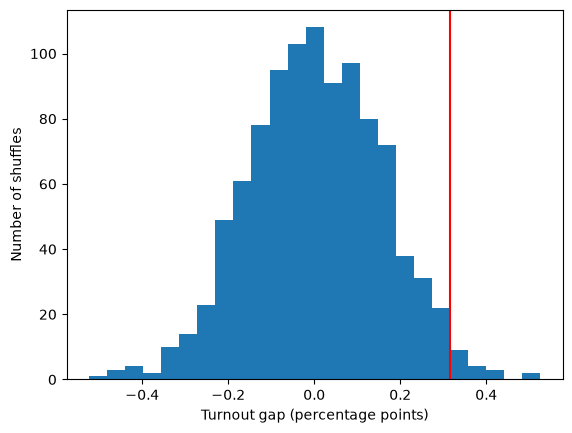

In [33]:
# Group the simulated gaps into 25 intervals and count how many fall in each.
plt.hist(fake_ates_pp, bins=25)
# Mark the observed gap with a red vertical line.
plt.axvline(observed_ate_pp, color='red')
# Label the horizontal axis with the effect and its units.
plt.xlabel('Turnout gap (percentage points)')
# Label the vertical axis with the number of shuffles.
plt.ylabel('Number of shuffles')
# Display the finished plot.
plt.show()


The p-value describes how unusual the sample's gap is under the stated null and
shuffling model. It is not the probability that the null is true. More shuffles
do not fix an incorrect model of assignment.


## Subgroups: the same calculation within each group

Pass two column names to `groupby` to calculate means for each combination of
past voting and assignment. `.unstack('treatment')` moves the treatment labels
from the row index into separate columns.

`.rename(columns={0: 'control', 1: 'treated'})` gives those columns readable names.
The braces contain a dictionary: each entry maps an old name to a new name.
Subtracting the two columns works row by row. Assigning to `['effect_pp']` adds
the resulting column. `.round(3)` displays the table rounded to three decimal places.

In [34]:
# Calculate mean turnout for each combination of past voting and assignment.
subgroups = calls.groupby(['gen2012', 'treatment'])['voted'].mean()
# Put the control and treatment means in separate columns.
subgroups = subgroups.unstack('treatment')
# Replace the numeric column labels with readable names.
subgroups = subgroups.rename(columns={0: 'control', 1: 'treated'})
# Calculate treatment minus control within each subgroup, in percentage points.
subgroups['effect_pp'] = 100 * (subgroups['treated'] - subgroups['control'])
# Display the table rounded to three decimal places.
subgroups.round(3)


treatment,control,treated,effect_pp
gen2012,,,
0,0.128,0.133,0.448
1,0.598,0.598,-0.028


These estimates can differ by chance. The table alone does not show that the true
effects differ, or that changing someone's past voting would change the effect.


## Exercise 1: Calculate an effect for one subgroup

1. Keep only voters in single-voter households (`svh` equals 1).
2. Calculate mean turnout for treatment and control in this subgroup. What is
   treatment minus control, in percentage points?

Use the same filtering and grouped-means steps as the worked examples.


In [35]:
%%ta_box code
### TA CODE ANSWER · Exercise 1.1


In [36]:
single_voters = calls[calls['svh'] == 1]
single_turnout = single_voters.groupby('treatment')['voted'].mean()
print(single_turnout)

single_effect = single_turnout.loc[1] - single_turnout.loc[0]
print('Effect:', round(100 * single_effect, 3), 'percentage points')


treatment
0    0.380131
1    0.388577
Name: voted, dtype: float64
Effect: 0.845 percentage points


**One sentence:** what does your estimated effect mean?


In [37]:
%%ta_box answer
### TA MODEL ANSWER · Exercise 1

Among single-voter households, assignment to calls increased estimated turnout
by about 0.845 percentage points, from 38.013% in control to 38.858% in treatment.


## Exercise 2: Canvassing in France

Use this new dataset to practice the grouped-means, regression, and permutation steps from the
robocall walkthrough. Read its description and load the table before answering
the questions. Each question has an answer cell below it.

### The dataset

**Vincent Pons (2018)** studied door-to-door canvassing during **François Hollande's
2012 French presidential campaign**. Volunteers discussed the election and the
candidate with residents. Official election returns measured participation and
candidate support. We focus on the **first round**, held on April 22, 2012.

**One row is one campaign area:** either a voting precinct or a whole municipality,
depending on where random assignment took place. Within local randomization blocks,
areas were assigned to a treatment pool or control, usually four to treatment and
one to control. The campaign then selected areas from the treatment pool for
canvassers to cover. Thus, `treatment` records **random assignment**, not whether
every area was visited or every voter had a conversation.

Our file contains **3,397 areas and eight columns**: 1,713 precincts and 1,684
municipalities, with 2,723 treatment areas and 674 controls. It keeps the paper's
main-sample territories, where campaign reports indicated use of the allocation
lists, and areas with matched 2012 election results. It is a teaching extract of
the replication data; there are **no missing values** in these eight columns.

| Column | Meaning |
|---|---|
| `area_id` | Unique area identifier created from the original municipality and precinct codes. |
| `area_type` | `Precinct` or `Municipality`: the unit represented by the row. |
| `municipality` | Municipality name. Several precincts can belong to the same municipality. |
| `block` | Identifier for the local group within which assignment was randomized. |
| `treatment` | 1 = assigned to the treatment pool; 0 = assigned to control. |
| `registered` | Number of registered voters in the area for the first round. |
| `turnout` | Ballots cast divided by registered voters in the first round. |
| `hollande_share` | Votes for Hollande divided by valid candidate votes in the first round; blank and invalid ballots are excluded from this denominator. |

Both outcomes are **proportions between 0 and 1**, not individual 0/1 votes.
Each area counts equally in our means. Multiply a mean by 100 for a percentage,
and a treatment–control difference by 100 for **percentage points**.

We calculate simple, unadjusted assignment differences. The paper also accounts
for randomization blocks and distinguishes assignment from allocation to canvassers,
so these calculations need not reproduce its headline estimates.

Sources: Pons (2018), [Will a Five-Minute Discussion Change Your Mind?](https://doi.org/10.1257/aer.20160524),
and the author's [replication package](https://doi.org/10.3886/E113130V1).
The [data notes](data/README.md) document the extract and original variable names.

### Load the exercise data

The teaching CSV is supplied in this week's `data` folder. In local Jupyter,
open the notebook from the Week 3 folder. In Colab, use the Files panel to create
a folder named `data` and upload `pons_2018_teaching.csv` into it.

Use `pd.read_csv()` to load the file, then `.head()` to see the first five areas.

In [3]:
pons = pd.read_csv('data/pons_2018_teaching.csv')
pons.head()

,area_id,area_type,municipality,block,treatment,registered,turnout,hollande_share
0,M_77208,Municipality,Gouaix,2914,1,990,0.774747,0.253333
1,M_91156,Municipality,Cheptainville,3324,0,1243,0.839099,0.263209
2,P_94068_31,Precinct,Saint-Maur-des-Fossés,3498,1,987,0.810537,0.285896
3,P_91421_4,Precinct,Montgeron,3363,0,979,0.785495,0.283622
4,P_94033_22,Precinct,Fontenay-sous-Bois,3481,1,941,0.776833,0.343137


### 1. Compare two outcomes

Using all areas, what are the treatment and control means for **turnout** and
**Hollande's vote share**? Report the means as percentages.

In [4]:
%%ta_box code
### TA CODE ANSWER · Exercise 2.1 · Means

In [5]:
pons_means = pons.groupby('treatment')[['turnout', 'hollande_share']].mean()
100 * pons_means

,turnout,hollande_share
treatment,,
0,79.512213,31.574841
1,79.500151,32.179044


For each outcome, what is treatment minus control, in **percentage points**?

In [6]:
%%ta_box code
### TA CODE ANSWER · Exercise 2.1 · Differences

In [7]:
pons_gaps_pp = 100 * (pons_means.loc[1] - pons_means.loc[0])
pons_gaps_pp

turnout          -0.012062
hollande_share    0.604203
dtype: float64

### 2. Check with a regression

Regress `hollande_share` on `treatment`. Does the treatment coefficient match
your difference in means? Report it in percentage points.

In [8]:
%%ta_box code
### TA CODE ANSWER · Exercise 2.2


In [9]:
hollande_model = smf.ols('hollande_share ~ treatment', data=pons).fit()
print('Regression estimate:', round(100 * hollande_model.params['treatment'], 3),
      'percentage points')


Regression estimate: 0.604 percentage points


### 3. Run a permutation test

Could the observed difference in Hollande's vote share arise by chance if
assignment changed no area's outcome? **You can copy and adapt the previous
permutation code.** Use `pons` and the outcome `hollande_share`.

There is one change: Pons randomized **within blocks**. Shuffle `treatment`
within each `block`, keeping each area's outcome fixed and preserving the
number of treatment and control areas in each block. For this teaching test,
condition on the areas and assignment counts retained in the extract.

**Small pandas hint:** `.sort_values('block')` returns the table in block order.
Then `groupby('block')` followed by `.sample(frac=1)` on the assignment column
shuffles within each block. With the table in block order, `.values` lines up
the shuffled labels with the correct rows, as in the earlier example.

**a. Set up.** What is the observed vote-share gap in percentage points?
Prepare the table in block order, set the seed to 2026, and make space for
1,000 simulated gaps.

In [10]:
%%ta_box code
### TA CODE ANSWER · Exercise 2.3a

In [11]:
pons_ri = pons.sort_values('block')
pons_observed_ate_pp = pons_gaps_pp['hollande_share']
np.random.seed(2026)
n_reps = 1000
pons_fake_ates = np.empty(n_reps)
print('Observed gap:', round(pons_observed_ate_pp, 3), 'percentage points')

Observed gap: 0.604 percentage points


**b. Repeat the shuffle.** How would you adapt the earlier loop to shuffle
assignments within blocks 1,000 times and store the treatment–control vote-share
gap from each shuffle?

In [12]:
%%ta_box code
### TA CODE ANSWER · Exercise 2.3b

In [13]:
for i in range(n_reps):
    shuffled_treatment = pons_ri.groupby('block')['treatment'].sample(frac=1).values
    pons_fake_ates[i] = (pons_ri['hollande_share'][shuffled_treatment == 1].mean()
                        - pons_ri['hollande_share'][shuffled_treatment == 0].mean())

**c. Calculate the p-value.** What fraction of the simulated gaps are at least
as large as the observed gap in absolute value? Use the same two-sided
comparison as in the worked example, with both gaps in percentage points.

In [14]:
%%ta_box code
### TA CODE ANSWER · Exercise 2.3c

In [15]:
pons_fake_ates_pp = 100 * pons_fake_ates
pons_n_as_extreme = int(np.sum(np.abs(pons_fake_ates_pp) >= abs(pons_observed_ate_pp)))
pons_p_value = pons_n_as_extreme / n_reps

print('Equally large or larger gaps:', pons_n_as_extreme, 'out of', n_reps)
print('Two-sided p-value:', pons_p_value)

Equally large or larger gaps: 10 out of 1000
Two-sided p-value: 0.01


**d. Explain briefly.** What does your p-value tell you about the sharp null?
Why should assignments be shuffled within blocks?

In [16]:
%%ta_box answer
### TA MODEL ANSWER · Exercise 2.3d

Only 10 of 1,000 permutations produced a gap at least as large in absolute value
as the observed +0.604 percentage points, giving a p-value of 0.010 and evidence
against the sharp null under this conditional permutation model. Shuffling within
blocks preserves the assignment groups used in the experiment and the treatment
counts retained in each block of the teaching extract.

### 4. Interpret in two sentences

What does the vote-share difference mean, and how does it compare with the
turnout difference you calculated? Do the two outcomes measure the same thing?

In [17]:
%%ta_box answer
### TA MODEL ANSWER · Exercise 2

Hollande's mean vote share was 32.179% in treatment areas and 31.575% in control,
a difference of +0.604 percentage points, matching the regression coefficient
after multiplying by 100. The turnout gap was only −0.012 percentage points:
turnout measures participation among registered voters, whereas vote share measures
support for Hollande among valid candidate votes.

These are unadjusted differences between assigned groups, not effects per voter
contacted. Their sizes alone do not establish statistical significance.
